For our multimodal task we need to train and use 2 models:  
An image classifier that gets an image of animal and predict one of the animal class and a NER model that takes a sequence and extracts animal words from it, so taking: "There is a cow in the picture" it should return "cow". Let's begin with the image classification part

## Image classification

Let's look at our animals dataset, this dataset is just photos from Google Search, so they are quite diverse. There are 10 classes in the dataset as you can see below: horse, sheep, elephant, cat, squirrel, chicken, spider, cow, dog, butterfly



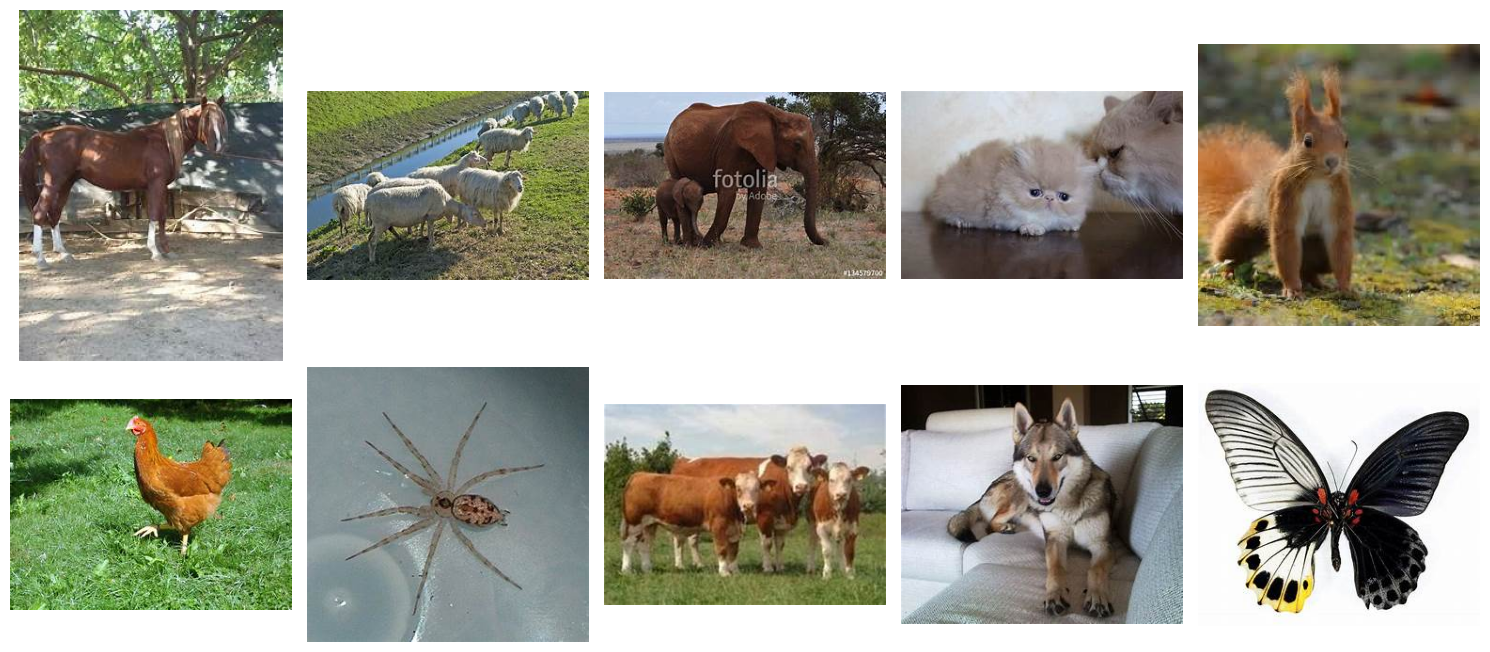

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# 2. Set root data directory
data_dir = '/kaggle/input/datasets/alessiocorrado99/animals10/raw-img'

# 3. & 4. Select random images for each class
images = []
animals = os.listdir(data_dir)
for animal in animals:
    folder_path = os.path.join(data_dir, animal)
    images.append(os.path.join(folder_path, os.listdir(folder_path)[0]))

# 5. Create a 2x5 subplot grid
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
axes = axes.flatten()

# 6. & 7. Display images and set titles
for i, img_path in enumerate(images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

The image classifier was trained on this dataset and now let's look at how the classifier perfoms on images that weren't taken from the dataset, actually these pictures are my own pictures of pets :)

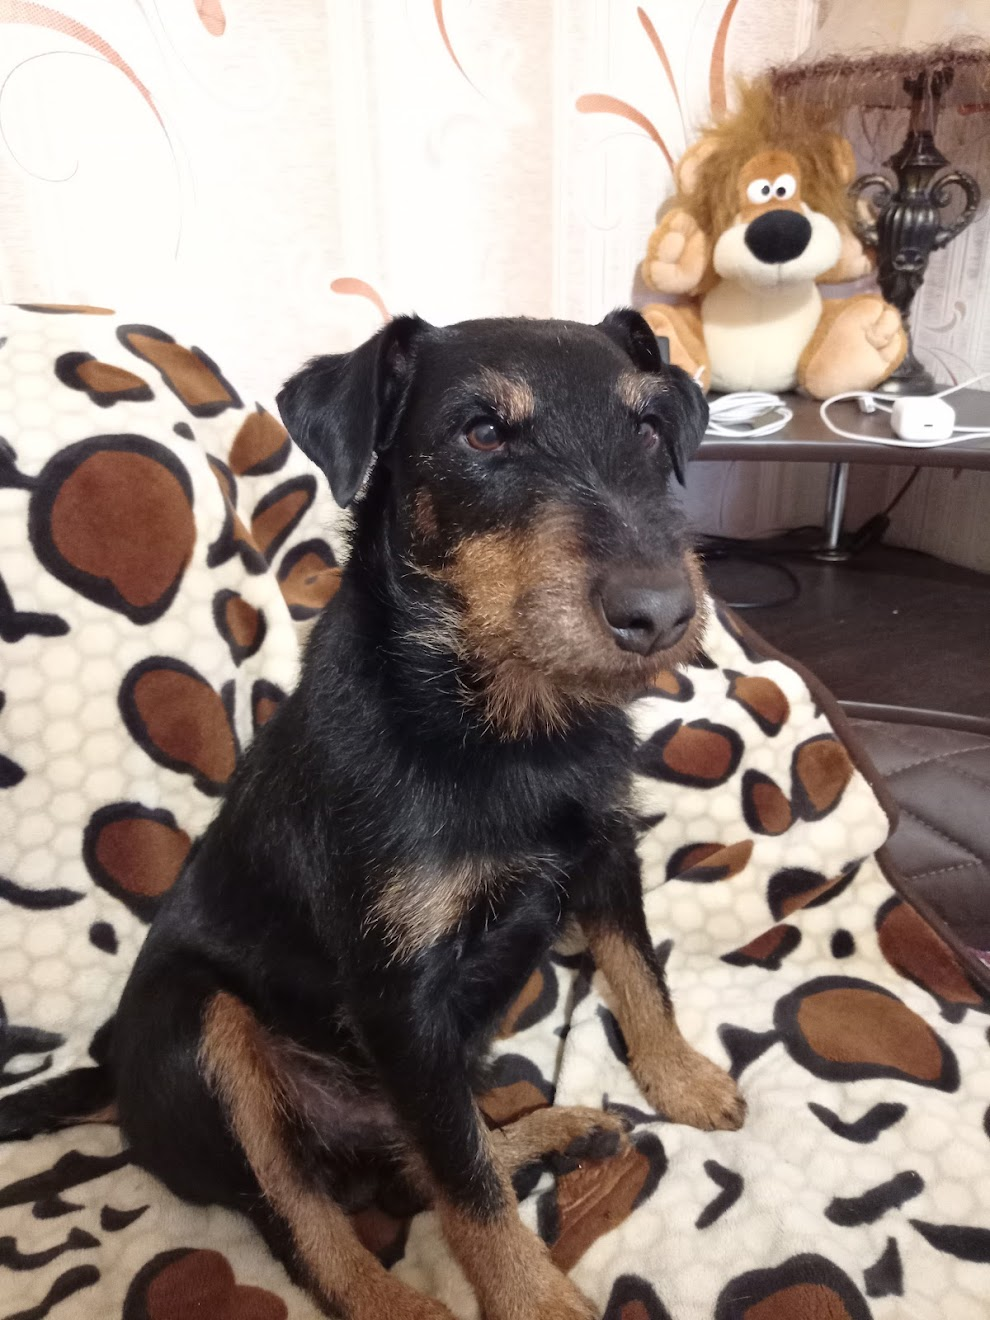

In [7]:
from IPython.display import Image, display

img_pth = "IMG_20210118_165825.jpg"
display(Image(filename=img_pth, height=440, width=330))

In [ ]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/IMG_inference.py --image "IMG_20210118_165825.jpg"

Prediction : dog (Confidence: 1.00)


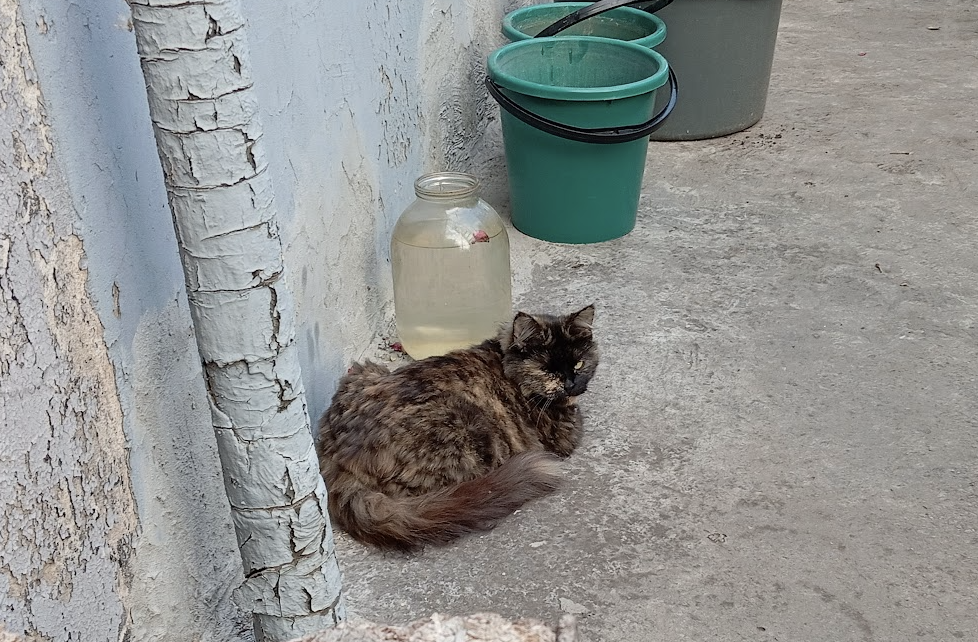

In [ ]:
img_pth =  "cat.png"
display(Image(filename=img_pth, width=489, height=321))


In [ ]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/IMG_inference.py --image "cat.png"

Prediction : cat (Confidence: 0.50)


The model chosen was classic ResNet-18, the shallowest version, because the task isn't too complex. We chose the ImageNet pretrained version, because our animal classficiation task is pretty similar to what the model has seen and fine-tuned it on our dataset for 3 epochs and got the val accuracy ~95%


## NER

The next part of our pipeline is the NER model. I chose a basic BERT model and fine-tuned it attaching a token-classification head. I was thinking of fine-tuning a NER pretrained option of BERT, but usually models were trained on quite a different NER task like locations and persons, which means that changing the head wasn't enough for this. 

Let's look at a dataset sample. The dataset is synthetic, generted with the help of ChatGPT, it's simple and fast, but  the quality may not be spectacular, but for our purposes it's sufficient enough, we're not gonna face complicated sentences

In [ ]:
!pip install seqeval

In [5]:
from NER_train import load_conll
sentences, labels = load_conll('/kaggle/input/datasets/nikitatkachuk/utilits/train.conll')

In [6]:
print(sentences[0])
print(labels[0])

['There', 'is', 'a', 'chickens', 'in', 'the', 'picture']
['O', 'O', 'O', 'B-ANIMAL', 'O', 'O', 'O']


The model was trained for 1 epoch, getting the ~100% accuracy and F1 score. Yes, because the dataset is simple, these scores are normal.   
Let's check how our model works:

In [22]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/NER_inference.py --model_dir /kaggle/working/models/ner_model/checkpoint-3000 --sentence "I saw a nice puppy today and fantastic birds!"

Loading weights: 100%|█| 199/199 [00:00<00:00, 2208.65it/s, Materializing param=
Sentence : I saw a nice puppy today and fantastic birds!
Animals  : ['puppy', 'birds']


In [15]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/NER_inference.py --model_dir /kaggle/working/models/ner_model/checkpoint-3000 --sentence "Hello, My name is Julia!"

Loading weights: 100%|█| 199/199 [00:00<00:00, 2062.37it/s, Materializing param=
No animals found


Although, sometimes the BERT can behave poorly with the animals it hasn't seen

In [36]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/NER_inference.py --model_dir /kaggle/working/models/ner_model/checkpoint-3000 --sentence "I was in the zoo and I liked the parrots, they were so beatiful!"

Loading weights: 100%|█| 199/199 [00:00<00:00, 1984.56it/s, Materializing param=
No animals found


In [37]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/NER_inference.py --model_dir /kaggle/working/models/ner_model/checkpoint-3000 --sentence "I was in the zoo and I liked the dogs, they were so beatiful!"

Loading weights: 100%|█| 199/199 [00:00<00:00, 1902.88it/s, Materializing param=
Sentence : I was in the zoo and I liked the dogs, they were so beatiful!
Animals  : ['dogs']


But the NER dataset was generated specifically for the Animals-10 dataset, so it's fine

## Pipeline

Finally, that's how the pipeline works

In [ ]:
# The dog pic from the dataset
!python /kaggle/input/datasets/nikitatkachuk/utilits/pipeline.py --image  "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg" --sentence "There is a dog!"

Loading weights: 100%|█| 199/199 [00:00<00:00, 1802.53it/s, Materializing param=
Sentence : There is a dog!
Image    : /kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
Result   : True


In [34]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/pipeline.py --image  "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg" --sentence "I can see a bird right here!"

Loading weights: 100%|█| 199/199 [00:00<00:00, 1922.47it/s, Materializing param=
Sentence : I can see a bird right here!
Image    : /kaggle/input/datasets/alessiocorrado99/animals10/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
Result   : False


Our model is robust to mentioning more than one animal

In [ ]:
#My dog pic here
!python /kaggle/input/datasets/nikitatkachuk/utilits/pipeline.py --image  "IMG_20210118_165825.jpg" --sentence "I see a cat and a dog here"

Loading weights: 100%|█| 199/199 [00:00<00:00, 2137.68it/s, Materializing param=
Sentence : I see a cat and a dog here
Image    : /kaggle/input/datasets/nikitatkachuk/utilits/IMG_20210118_165825.jpg
Result   : False


In [ ]:
!python /kaggle/input/datasets/nikitatkachuk/utilits/pipeline.py --image  "IMG_20210118_165825.jpg" --sentence "I see only a dog here"

Loading weights: 100%|█| 199/199 [00:00<00:00, 1934.33it/s, Materializing param=
Sentence : I see only a dog here
Image    : /kaggle/input/datasets/nikitatkachuk/utilits/IMG_20210118_165825.jpg
Result   : True
